# Lab 10: Learning the XOR Boolean Function Using an MLP
**Aim**
To understand how to implement neural networks using different deep learning libraries (Keras, PyTorch, and TensorFlow) and solve the non-linear XOR problem.

## 1. Imports and Dataset

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# XOR Dataset
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=np.float32)
y = np.array([[0], [1], [1], [0]], dtype=np.float32)

def plot_decision_boundary(model, X, y, title, is_pytorch=False, is_tf_lowlevel=False):
    x_min, x_max = -0.5, 1.5
    y_min, y_max = -0.5, 1.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))
    
    grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)
    
    if is_pytorch:
        with torch.no_grad():
            preds = model(torch.tensor(grid)).numpy()
    elif is_tf_lowlevel:
        preds = model(grid).numpy()
    else:
        preds = model.predict(grid, verbose=0)
        
    Z = (preds > 0.5).astype(int)
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')
    plt.scatter(X[:, 0], X[:, 1], c=y.ravel(), edgecolor='k', s=100, cmap='bwr')
    plt.title(title)
    plt.show()

I0000 00:00:1786776211.208104  402233 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1786776212.819159  402233 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## 2. Keras Implementation

/home/hery/.local/share/mise/installs/python/3.11.15/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
W0000 00:00:1786776213.249556  402233 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Keras Predictions:
[[0.]
 [1.]
 [1.]
 [0.]]


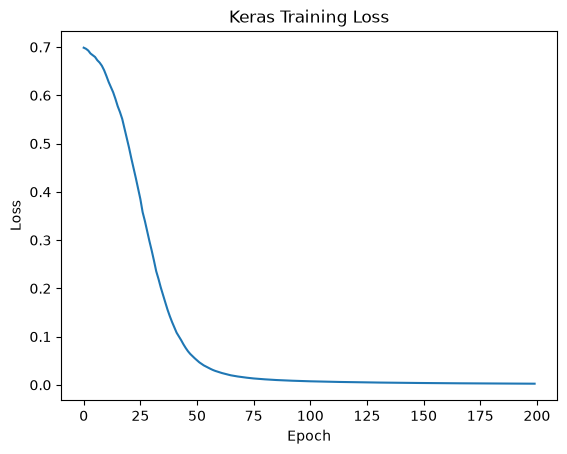

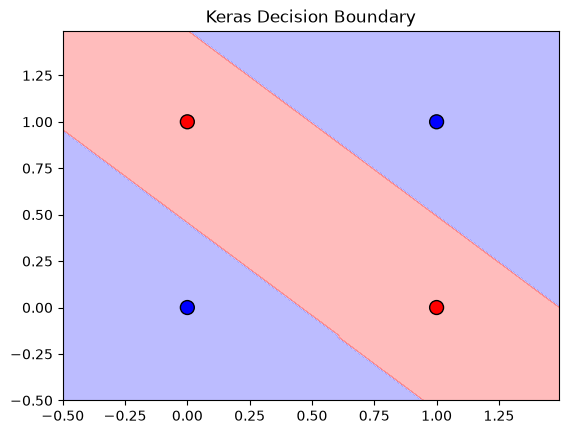

In [2]:
keras_model = Sequential([
    Dense(4, input_dim=2, activation='relu'),
    Dense(1, activation='sigmoid')
])

keras_model.compile(loss='binary_crossentropy', optimizer=tf.keras.optimizers.Adam(learning_rate=0.1), metrics=['accuracy'])

keras_history = keras_model.fit(X, y, epochs=200, verbose=0)

print("Keras Predictions:")
print(np.round(keras_model.predict(X, verbose=0)))

plt.plot(keras_history.history['loss'])
plt.title('Keras Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

plot_decision_boundary(keras_model, X, y, "Keras Decision Boundary")

## 3. PyTorch Implementation

In [3]:
class PyTorchMLP(nn.Module):
    def __init__(self):
        super(PyTorchMLP, self).__init__()
        self.hidden = nn.Linear(2, 4)
        self.relu = nn.ReLU()
        self.output = nn.Linear(4, 1)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        x = self.relu(self.hidden(x))
        x = self.sigmoid(self.output(x))
        return x

torch_model = PyTorchMLP()
criterion = nn.BCELoss()
optimizer = optim.Adam(torch_model.parameters(), lr=0.1)

X_torch = torch.tensor(X)
y_torch = torch.tensor(y)

torch_losses = []
for epoch in range(200):
    optimizer.zero_grad()
    outputs = torch_model(X_torch)
    loss = criterion(outputs, y_torch)
    loss.backward()
    optimizer.step()
    torch_losses.append(loss.item())

print("PyTorch Predictions:")
with torch.no_grad():
    print(torch.round(torch_model(X_torch)).numpy())

plt.plot(torch_losses)
plt.title('PyTorch Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

plot_decision_boundary(torch_model, X, y, "PyTorch Decision Boundary", is_pytorch=True)

## 4. TensorFlow Low-Level API

In [ ]:
class TFLowLevelMLP(tf.Module):
    def __init__(self):
        self.W1 = tf.Variable(tf.random.normal([2, 4]), name='W1')
        self.b1 = tf.Variable(tf.zeros([4]), name='b1')
        self.W2 = tf.Variable(tf.random.normal([4, 1]), name='W2')
        self.b2 = tf.Variable(tf.zeros([1]), name='b2')
        
    def __call__(self, x):
        hidden = tf.nn.relu(tf.matmul(x, self.W1) + self.b1)
        output = tf.sigmoid(tf.matmul(hidden, self.W2) + self.b2)
        return output

tf_model = TFLowLevelMLP()
optimizer = tf.optimizers.Adam(learning_rate=0.1)

def loss_fn(y_true, y_pred):
    return tf.reduce_mean(tf.keras.losses.binary_crossentropy(y_true, y_pred))

tf_losses = []
for epoch in range(200):
    with tf.GradientTape() as tape:
        preds = tf_model(X)
        loss = loss_fn(y, preds)
    grads = tape.gradient(loss, tf_model.trainable_variables)
    optimizer.apply_gradients(zip(grads, tf_model.trainable_variables))
    tf_losses.append(loss.numpy())

print("TF Low-Level Predictions:")
print(np.round(tf_model(X).numpy()))

plt.plot(tf_losses)
plt.title('TF Low-Level Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

plot_decision_boundary(tf_model, X, y, "TF Low-Level Decision Boundary", is_tf_lowlevel=True)

## Conclusion

The XOR problem is not linearly separable, meaning a single-layer perceptron cannot solve it. Adding a hidden layer with non-linear activation functions (like ReLU) enables the Multi-Layer Perceptron (MLP) to learn the required decision boundary.

- **Learning Rate**: Higher learning rates (e.g., 0.1) help the model converge faster for this simple problem. Lower learning rates (e.g., 0.001) might require significantly more epochs to reach the same loss.
- **Epochs**: Training for more epochs allows the network to learn the weights better, decreasing the loss until it plateaus.
- **Neurons**: A hidden layer with at least 2 neurons is required to solve XOR. Using 4 neurons makes it easier and faster to find a good local minimum.